# Classification d’images sur CIFAR-10
## Du CNN personnel au transfert d’apprentissage

**Question : comment améliorer un petit CNN, puis comparer un modèle entraîné depuis zéro à ResNet18 préentraîné ?**

Ce projet étudie la régularisation, l’architecture, le taux d’apprentissage et le fine-tuning. Le CNN personnel atteint **85,88 %** sur le test ; ResNet18 atteint **90,14 %**. Les fichiers de poids ont été réévalués après remise en ordre du notebook, sans nouvel entraînement.

### Lecture et exécution

- `MODE = "report"` (défaut) : affiche les résultats JSON et les graphiques ; aucun dataset, poids ou accès réseau n’est nécessaire.
- `MODE = "evaluate"` : charge les deux poids sélectionnés dans `models/` et recalcule validation, test et matrices.
- `MODE = "train"` : entraîne les expériences depuis zéro, puis évalue les deux modèles finaux. Les nouveaux résultats sont écrits dans un dossier horodaté sous `runs/`.

Exécuter les cellules dans l’ordre depuis la racine du projet ou `notebooks/`. Les résultats publiés restent dans `results/` et ne sont jamais écrasés par une nouvelle exécution. Les poids et le dataset ne sont pas inclus dans le dépôt Git courant.

Les explications et les cellules suivent le même ordre : données → architectures → apprentissage → validation → test → erreurs. Une nouvelle exécution peut différer numériquement : la graine ne garantit pas le déterminisme entre tous les environnements.

## 1. Protocole expérimental

| Ensemble | Taille | Rôle |
|---|---:|---|
| Entraînement | 40 000 | Calcul des gradients et mises à jour |
| Validation | 10 000 | Comparaisons et choix des sauvegardes |
| Test officiel | 10 000 | Évaluation des configurations fixées |

CIFAR-10 contient dix classes équilibrées. Une image RGB de 32 × 32 possède 3 072 valeurs. La séparation train/validation utilise la graine 42 et les mêmes indices dans toutes les expériences. Le test ne sert pas à régler les hyperparamètres.

**Traçabilité de la référence :** l’ancien historique du petit CNN ne contient que cinq époques et ne correspond pas aux sorties de dix époques du brouillon. Son score est donc exclu du comparatif publié. Son architecture et son protocole de dix époques sont conservés ci-dessous pour une nouvelle expérience reproductible. Aucun score manquant n’a été inventé.

Les autres historiques correspondent aux dernières sorties enregistrées. Les métriques des deux modèles finaux sont associées au SHA-256 de leurs poids dans `verified_metrics.json`.

## 2. Imports et configuration

Le mode rapport est conçu pour fonctionner sans les gros fichiers. Les deux autres modes nécessitent PyTorch, les données et, pour la réévaluation, les sauvegardes locales. Le réentraînement de ResNet18 télécharge ses poids ImageNet si nécessaire.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import random
import time
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

MODE = "report"  # "report", "evaluate" ou "train"
assert MODE in {"report", "evaluate", "train"}
SEED = 42
BATCH_SIZE = 64
RESNET_BATCH_SIZE = 32
LEARNING_RATE = 1e-3
FINETUNE_LEARNING_RATE = 1e-5

cwd = Path.cwd()
PROJECT_DIR = cwd.parent if cwd.name == "notebooks" else cwd
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
PUBLISHED_RESULTS = PROJECT_DIR / "results"
RUN_DIR = None
if MODE != "report":
    RUN_DIR = PROJECT_DIR / "runs" / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    for folder in ("models", "results", "figures"):
        (RUN_DIR / folder).mkdir(parents=True, exist_ok=True)
    import torch
    import torch.nn as nn
    from torchvision import datasets, transforms
    from torchvision.models import resnet18, ResNet18_Weights
    from torch.utils.data import DataLoader, random_split, Subset
    random.seed(SEED)
    torch.manual_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Appareil :", device)

with open(PUBLISHED_RESULTS / "experiment_histories.json", encoding="utf-8") as file:
    histories = json.load(file)
with open(PUBLISHED_RESULTS / "verified_metrics.json", encoding="utf-8") as file:
    results = json.load(file)
print("Mode :", MODE)
print("Projet :", PROJECT_DIR)

Mode : report
Projet : C:\Users\Paul Belleguic\Documents\ChatGPT\Projet\recuperation_cnn\github_ready


## 3. Préparation des images et lots

`ToTensor()` transforme CIFAR-10 en `[canaux, hauteur, largeur]` et ramène les valeurs dans `[0,1]`. Un lot de 64 images a la forme `[64,3,32,32]` ; les étiquettes ont la forme `[64]`.

Un retournement horizontal aléatoire (`p=0.5`) conserve l’étiquette. Il s’applique uniquement à l’entraînement ; les indices sont partagés, pas les transformations aléatoires. Cela ne crée pas de fichiers ni ne double la taille du dataset.

ResNet18 utilise le prétraitement associé à ses poids : redimensionnement, recadrage central 224 × 224 et normalisation des canaux. L’agrandissement ne crée pas de détails. Les lots sont réduits à 32. Pour cette expérience, son entraînement utilise ce prétraitement déterministe, sans les retournements du CNN.

Le mélange du DataLoader change l’ordre des images à chaque époque, pas la séparation. Une époque du CNN contient 625 lots de 64.

In [2]:
if MODE != "report":
    plain_transform = transforms.ToTensor()
    augmented_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5), transforms.ToTensor()
    ])
    weights = ResNet18_Weights.IMAGENET1K_V1
    resnet_transform = weights.transforms()

    full_train = datasets.CIFAR10(str(DATA_DIR), train=True, download=True,
                                  transform=plain_transform)
    train_data, val_data = random_split(
        full_train, [40000, 10000], generator=torch.Generator().manual_seed(SEED))
    assert set(train_data.indices).isdisjoint(val_data.indices)

    augmented_data = datasets.CIFAR10(str(DATA_DIR), train=True, download=False,
                                      transform=augmented_transform)
    resnet_data = datasets.CIFAR10(str(DATA_DIR), train=True, download=False,
                                  transform=resnet_transform)

    def make_loader(dataset, batch_size, shuffle=False):
        # Générateur indépendant : les démonstrations ne consomment pas son état.
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                          generator=torch.Generator().manual_seed(SEED), num_workers=0)

    train_loader = make_loader(train_data, BATCH_SIZE, True)
    augmented_loader = make_loader(Subset(augmented_data, train_data.indices), BATCH_SIZE, True)
    val_loader = make_loader(val_data, BATCH_SIZE)
    resnet_train_loader = make_loader(Subset(resnet_data, train_data.indices), RESNET_BATCH_SIZE, True)
    resnet_val_loader = make_loader(Subset(resnet_data, val_data.indices), RESNET_BATCH_SIZE)
    print("Entraînement :", len(train_data), "| Validation :", len(val_data))

## 4. Architectures

### Petit CNN et dropout

Une convolution partage ses filtres entre les positions. Chaque filtre combine tous les canaux d’entrée. ReLU applique `max(0,x)` et introduit une non-linéarité. Le max pooling 2 × 2 réduit chaque dimension spatiale de moitié.

Le petit CNN utilise deux blocs 3 → 16 → 32 canaux, puis un aplatissement de 32 × 8 × 8 vers dix logits. Sa variante ajoute `Dropout(0.3)` avant la couche finale : des activations sont masquées aléatoirement pendant l’entraînement, pas les poids. Le dropout est désactivé en évaluation.

Les affectations redondantes du brouillon ont été retirées ; cela conserve l’architecture utile mais peut changer l’initialisation aléatoire d’une nouvelle exécution.

In [3]:
if MODE != "report":
    class SmallCNN(nn.Module):
        def __init__(self, dropout=0.0):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
            )
            self.classifier = nn.Sequential(
                nn.Flatten(), nn.Dropout(dropout), nn.Linear(32 * 8 * 8, 10)
            )

        def forward(self, x):
            return self.classifier(self.features(x))

### CNN personnel amélioré

Six convolutions sont réparties en trois blocs. Chaque convolution est suivie de BatchNorm et ReLU. Le modèle compte **288 746 paramètres**.

BatchNorm utilise les statistiques du lot pendant l’entraînement et des statistiques mémorisées en évaluation ; elle apprend aussi une échelle et un décalage. Le biais de la convolution est désactivé ici car il est redondant avec cette normalisation.

Le pooling moyen global résume chaque carte par sa moyenne : la tête reçoit 128 valeurs au lieu de 2 048. Cela réduit ses paramètres, mais abandonne la position précise des activations. Plusieurs éléments changent ensemble : nous n’attribuons pas le gain à BatchNorm seule.

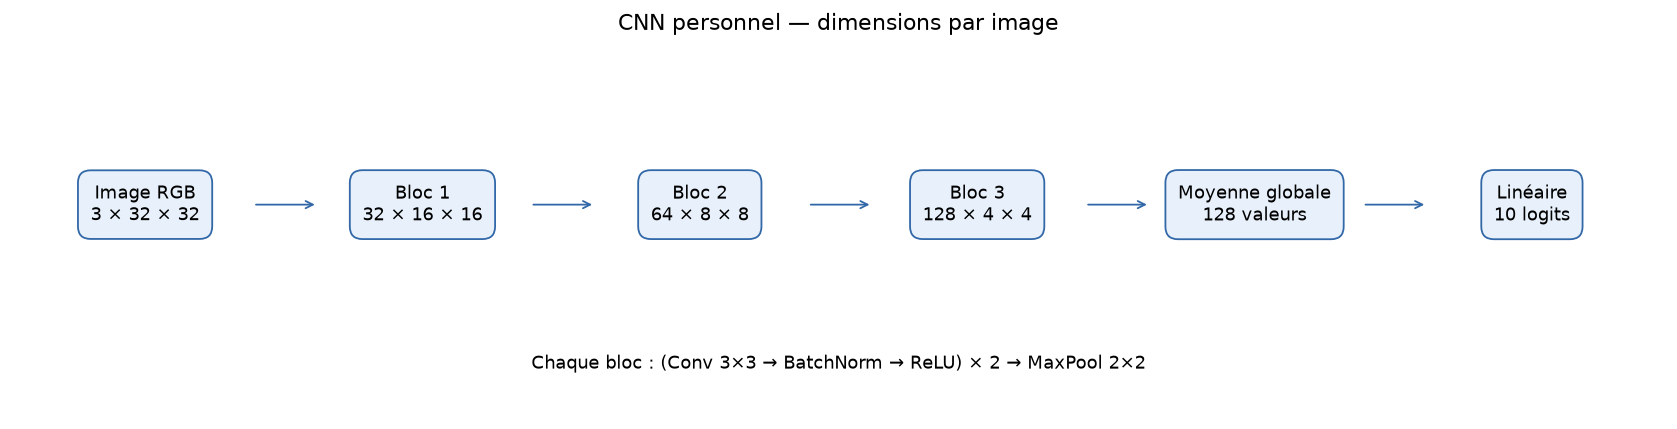

In [4]:
# Schéma de l’architecture ; aucune image générée ni poids nécessaire.
fig, ax = plt.subplots(figsize=(13, 3.4))
ax.axis("off")
stages = ["Image RGB\n3 × 32 × 32", "Bloc 1\n32 × 16 × 16",
          "Bloc 2\n64 × 8 × 8", "Bloc 3\n128 × 4 × 4",
          "Moyenne globale\n128 valeurs", "Linéaire\n10 logits"]
for i, text in enumerate(stages):
    x = 0.08 + i * 0.168
    ax.text(x, 0.58, text, ha="center", va="center", transform=ax.transAxes,
            fontsize=10, bbox=dict(boxstyle="round,pad=0.7", fc="#e8f1fb", ec="#3268a8"))
    if i < len(stages)-1:
        ax.annotate("", xy=(x+0.105, 0.58), xytext=(x+0.065, 0.58),
                    xycoords="axes fraction", arrowprops=dict(arrowstyle="->", color="#3268a8"))
ax.text(0.5, 0.13, "Chaque bloc : (Conv 3×3 → BatchNorm → ReLU) × 2 → MaxPool 2×2",
        ha="center", transform=ax.transAxes)
ax.set_title("CNN personnel — dimensions par image", pad=12)
plt.tight_layout()
plt.show()

In [5]:
if MODE != "report":
    class ImprovedCNN(nn.Module):
        def __init__(self):
            super().__init__()
    
            self.block1 = nn.Sequential(
                nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(32),
                nn.ReLU(),
    
                nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(32),
                nn.ReLU(),
    
                nn.MaxPool2d(kernel_size=2, stride=2)
            )
    
            self.block2 = nn.Sequential(
                nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(64),
                nn.ReLU(),
    
                nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(64),
                nn.ReLU(),
    
                nn.MaxPool2d(kernel_size=2, stride=2)
            )
    
            self.block3 = nn.Sequential(
                nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(128),
                nn.ReLU(),
    
                nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(128),
                nn.ReLU(),
    
                nn.MaxPool2d(kernel_size=2, stride=2)
            )
    
            self.classifier = nn.Sequential(
                nn.AdaptiveAvgPool2d((1, 1)),
                nn.Flatten(),
                nn.Linear(128, 10)
            )
            
        def forward(self, x):
            x = self.block1(x)
            x = self.block2(x)
            x = self.block3(x)
            x = self.classifier(x)
            return x

### ResNet18 et transfert d’apprentissage

Des blocs résiduels combinent une transformation `F(x)` avec une connexion directe. L’architecture et le préentraînement sont deux notions distinctes : les poids utilisés ici ont déjà appris sur ImageNet.

Phase 1 : geler la partie préentraînée et remplacer `fc` par `Linear(512,10)` — **5 130 paramètres entraînables**. Phase 2 : repartir de la meilleure sauvegarde et dégeler aussi `layer4`, avec un taux plus faible.

Les statistiques BatchNorm restent fixes dans les deux phases (`eval()`). Les paramètres autorisés par `requires_grad` reçoivent néanmoins leurs gradients. Le mode évaluation ne désactive pas la différentiation.

In [6]:
if MODE != "report":
    def build_resnet(pretrained=False):
        model = resnet18(weights=weights if pretrained else None)
        for parameter in model.parameters():
            parameter.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, 10)
        return model

## 5. Perte, gradients et boucles

La cross-entropy reçoit les logits directement, sans softmax ajouté. `argmax(dim=1)` donne l’indice du score maximal. L’accuracy compte les bonnes réponses ; la perte reflète aussi les scores et peut augmenter même si l’accuracy progresse.

Une mise à jour suit : **zero_grad → passage avant → perte → backward → step**. Les gradients sont remis à zéro car PyTorch les accumule par défaut. `backward()` les calcule ; Adam modifie ensuite les paramètres.

La perte moyenne du lot est pondérée par sa taille avant accumulation. `evaluate` n’ajuste aucun paramètre. La sauvegarde de la meilleure perte de validation n’arrête pas l’entraînement : aucun early stopping automatique n’est utilisé.

In [7]:
if MODE != "report":
    criterion = nn.CrossEntropyLoss()

    def train_one_epoch(model, loader, optimizer, freeze_bn=False):
        if freeze_bn:
            model.eval()
            model.fc.train()
        else:
            model.train()
        loss_sum = correct = count = 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            size = labels.size(0)
            loss_sum += loss.item() * size
            correct += (outputs.argmax(1) == labels).sum().item()
            count += size
        return loss_sum / count, correct / count

    def evaluate(model, loader, collect=False):
        model.eval()
        loss_sum = correct = count = 0
        actuals, predictions = [], []
        with torch.no_grad():
            for images, labels in loader:
                outputs = model(images.to(device))
                loss = criterion(outputs, labels.to(device))
                predicted = outputs.argmax(1).cpu()
                size = labels.size(0)
                loss_sum += loss.item() * size
                correct += (predicted == labels).sum().item()
                count += size
                if collect:
                    actuals.extend(labels.tolist())
                    predictions.extend(predicted.tolist())
        return {"loss": loss_sum/count, "accuracy": correct/count, "count": count}, actuals, predictions

    def fit(model, loader, validation_loader, optimizer, epochs, name,
            history=None, freeze_bn=False, best_loss=float("inf")):
        if history is None:
            history = {key: [] for key in ("train_loss", "val_loss", "train_accuracy", "val_accuracy")}
        checkpoint = RUN_DIR / "models" / f"{name}_best.pth"
        for _ in range(epochs):
            tr_loss, tr_acc = train_one_epoch(model, loader, optimizer, freeze_bn)
            validation, _, _ = evaluate(model, validation_loader)
            history["train_loss"].append(tr_loss)
            history["train_accuracy"].append(tr_acc)
            history["val_loss"].append(validation["loss"])
            history["val_accuracy"].append(validation["accuracy"])
            if validation["loss"] < best_loss:
                best_loss = validation["loss"]
                torch.save(model.state_dict(), checkpoint)
            with open(RUN_DIR / "results" / f"{name}_history.json", "w", encoding="utf-8") as file:
                json.dump(history, file, indent=2)
            print(f"{name} — époque {len(history['train_loss'])} | "
                  f"train {tr_loss:.4f}, {tr_acc:.2%} | "
                  f"validation {validation['loss']:.4f}, {validation['accuracy']:.2%}")
        return history, best_loss, checkpoint

## 6. Réentraînement optionnel des expériences

Ces cellules ne s’exécutent qu’en mode `train`. Chaque expérience réinitialise ses poids et son optimiseur. Les nouvelles courbes seront distinctes des résultats publiés ; les générateurs des loaders sont désormais explicitement réinitialisés pour chaque expérience.

| Expérience | Architecture | Augmentation | Époques | Taux |
|---|---|---|---:|---|
| Référence | Petit CNN | Aucune | 10 | 0,001 |
| Dropout | Petit CNN + dropout 0,3 | Aucune | 10 | 0,001 |
| Augmentation | Petit CNN + dropout 0,3 | Flip horizontal | 10 | 0,001 |
| CNN amélioré | Six convolutions + BN | Flip horizontal | 15 | 0,001 puis 0,0001 après 10 |
| ResNet18, tête | ImageNet, tête seule | Aucune | 5 | 0,001 |
| ResNet18, fine-tuning | `layer4` + tête | Aucune | 3 | 0,00001 |

Les trois petits CNN sont comparés à leur dernière époque. Les deux modèles finaux sont sélectionnés par perte minimale de validation. Les budgets et prétraitements différents doivent rester explicites.

In [8]:
if MODE == "train":
    histories = {}
    for name, dropout, dataset in (
        ("baseline", 0.0, train_data),
        ("dropout", 0.3, train_data),
        ("augmentation", 0.3, Subset(augmented_data, train_data.indices))
    ):
        torch.manual_seed(SEED)
        candidate = SmallCNN(dropout).to(device)
        optimizer = torch.optim.Adam(candidate.parameters(), lr=LEARNING_RATE)
        loader = make_loader(dataset, BATCH_SIZE, True)
        histories[name], _, _ = fit(candidate, loader, val_loader, optimizer, 10, name)
        torch.save(candidate.state_dict(), RUN_DIR / "models" / f"{name}_last.pth")
        candidate.cpu()
        del optimizer, candidate

In [9]:
if MODE == "train":
    torch.manual_seed(SEED)
    candidate = ImprovedCNN().to(device)
    optimizer = torch.optim.Adam(candidate.parameters(), lr=LEARNING_RATE)
    loader = make_loader(Subset(augmented_data, train_data.indices), BATCH_SIZE, True)
    history, best_loss, cnn_path = fit(candidate, loader, val_loader, optimizer, 10, "improved_cnn")
    for group in optimizer.param_groups:
        group["lr"] = LEARNING_RATE / 10
    histories["improved_cnn"], _, cnn_path = fit(
        candidate, loader, val_loader, optimizer, 5, "improved_cnn", history, best_loss=best_loss)
    candidate.cpu()
    del optimizer, candidate

In [10]:
if MODE == "train":
    torch.manual_seed(SEED)
    candidate = build_resnet(pretrained=True).to(device)
    optimizer = torch.optim.Adam(candidate.fc.parameters(), lr=LEARNING_RATE)
    histories["resnet_head"], head_loss, head_path = fit(
        candidate, resnet_train_loader, resnet_val_loader, optimizer, 5,
        "resnet_head", freeze_bn=True)
    candidate.load_state_dict(torch.load(head_path, map_location=device, weights_only=True))
    for parameter in candidate.layer4.parameters():
        parameter.requires_grad = True
    optimizer = torch.optim.Adam((p for p in candidate.parameters() if p.requires_grad),
                                 lr=FINETUNE_LEARNING_RATE)
    # Préserve le point de départ si le fine-tuning n’améliore pas la validation.
    resnet_path = RUN_DIR / "models" / "resnet_finetuning_best.pth"
    torch.save(candidate.state_dict(), resnet_path)
    histories["resnet_finetuning"], _, resnet_path = fit(
        candidate, resnet_train_loader, resnet_val_loader, optimizer, 3,
        "resnet_finetuning", freeze_bn=True, best_loss=head_loss)
    candidate.cpu()
    del optimizer, candidate
    with open(RUN_DIR / "results" / "experiment_histories.json", "w", encoding="utf-8") as file:
        json.dump(histories, file, indent=2)

## 7. Résultats de validation

Le tableau est calculé depuis les historiques, plutôt que recopié à la main. Pour les modèles finaux, il donne l’époque où la perte est minimale ; pour les petits CNN, il donne la dernière époque du protocole. La ligne de référence n’est ajoutée que si une nouvelle expérience complète est disponible.

In [11]:
names = {"baseline": "CNN de référence", "dropout": "CNN + dropout",
         "augmentation": "CNN + dropout + flip", "improved_cnn": "CNN amélioré",
         "resnet_head": "ResNet18 — tête", "resnet_finetuning": "ResNet18 — fine-tuning"}
rows = ["| Expérience | Époques | Époque présentée | Perte validation | Accuracy validation |",
        "|---|---:|---:|---:|---:|"]
for name, history in histories.items():
    assert len({len(values) for values in history.values()}) == 1
    index = (len(history["val_loss"])-1 if name in {"baseline", "dropout", "augmentation"}
             else min(range(len(history["val_loss"])), key=lambda i: history["val_loss"][i]))
    rows.append(f"| {names[name]} | {len(history['val_loss'])} | {index+1} | "
                f"{history['val_loss'][index]:.4f} | {history['val_accuracy'][index]:.2%} |")
display(Markdown("\n".join(rows)))

| Expérience | Époques | Époque présentée | Perte validation | Accuracy validation |
|---|---:|---:|---:|---:|
| CNN + dropout | 10 | 10 | 0.9724 | 66.69% |
| CNN + dropout + flip | 10 | 10 | 0.9932 | 65.63% |
| CNN amélioré | 15 | 13 | 0.3929 | 86.79% |
| ResNet18 — tête | 5 | 5 | 0.3851 | 86.41% |
| ResNet18 — fine-tuning | 3 | 3 | 0.2720 | 90.61% |

### Courbes d’apprentissage

La perte d’entraînement est une moyenne pendant les mises à jour ; la validation utilise les poids en fin d’époque. Dropout et augmentation rendent aussi les conditions d’entraînement différentes. Un écart seul n’établit donc pas le surapprentissage.

Sur les résultats publiés, la réduction du taux du CNN après dix époques améliore nettement la validation. Sa perte atteint son minimum à l’époque 13, puis remonte légèrement. ResNet18 progresse pendant les trois époques de fine-tuning ; un écart train/validation persiste.

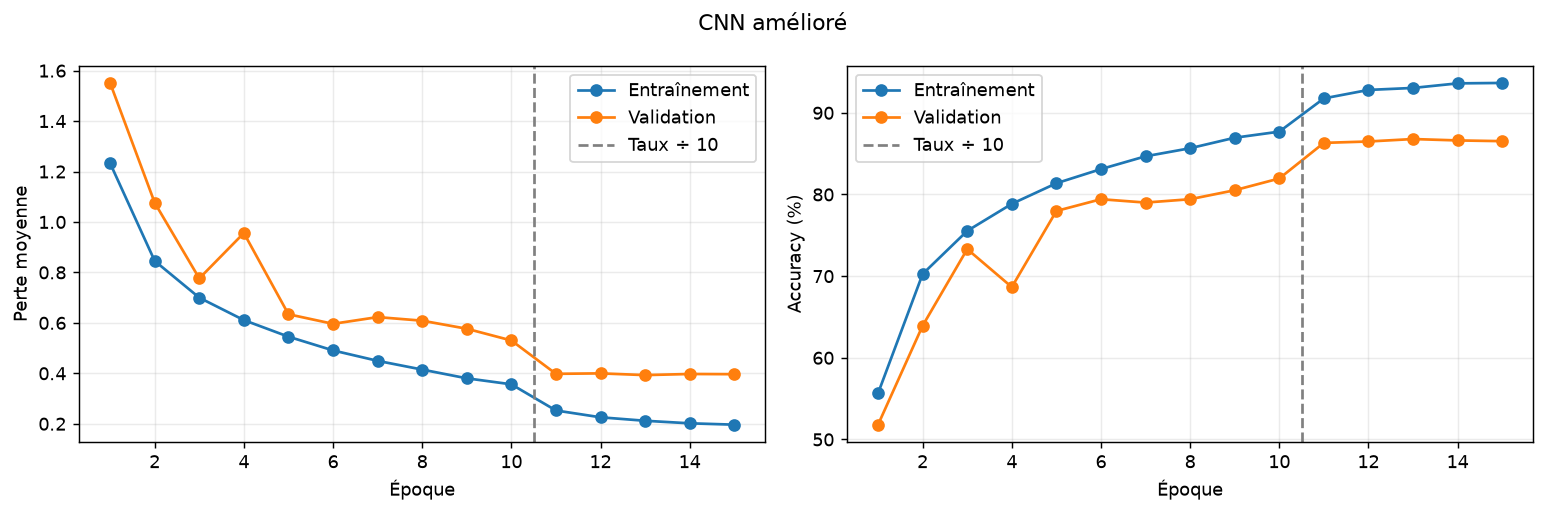

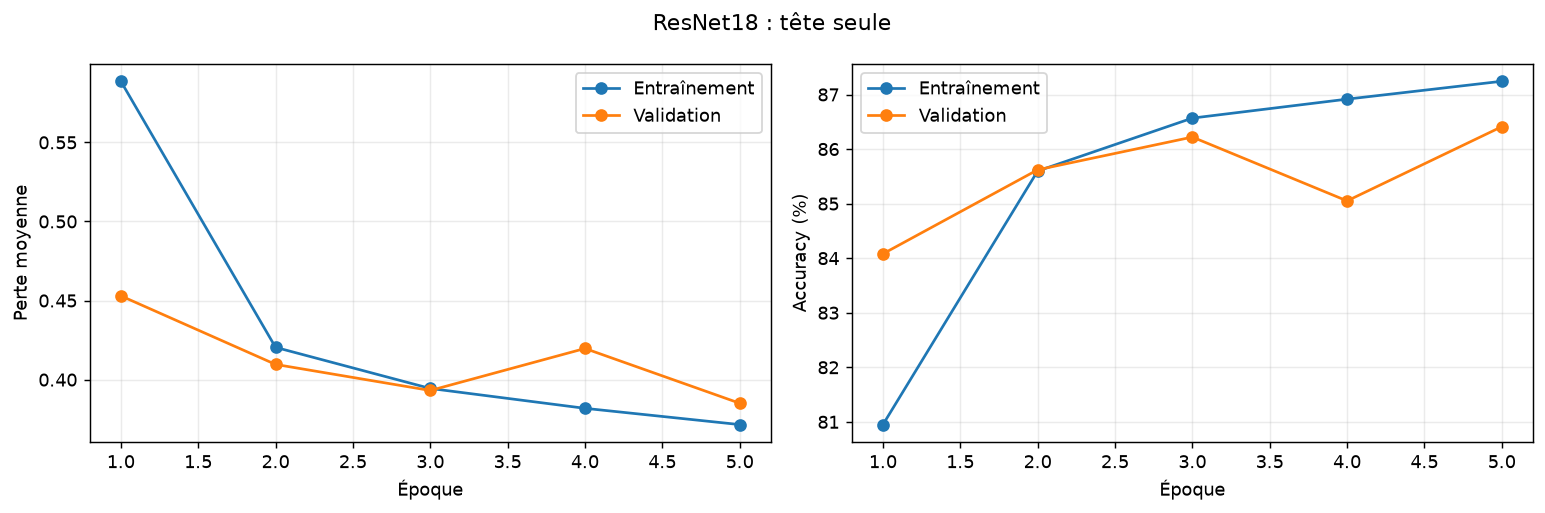

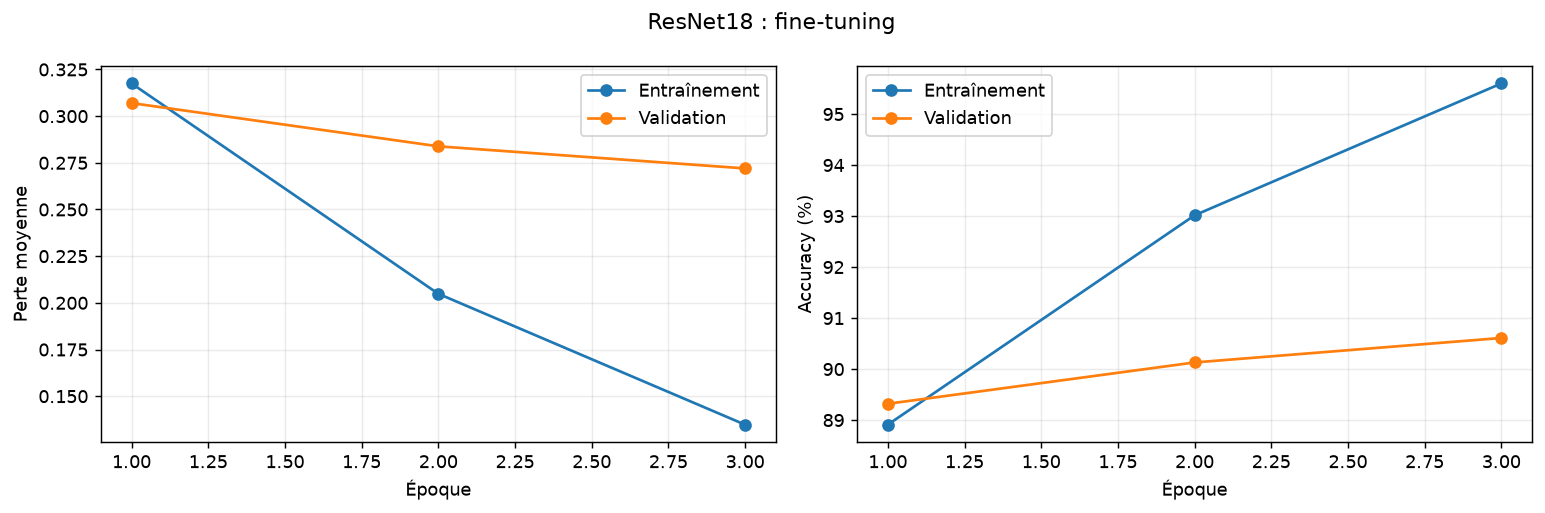

In [12]:
def plot_learning_curves(history, title, lr_change=None):
    epochs = list(range(1, len(history["train_loss"])+1))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for prefix, label in (("train", "Entraînement"), ("val", "Validation")):
        axes[0].plot(epochs, history[f"{prefix}_loss"], marker="o", label=label)
        axes[1].plot(epochs, [100*x for x in history[f"{prefix}_accuracy"]], marker="o", label=label)
    for ax in axes:
        if lr_change:
            ax.axvline(lr_change, color="gray", linestyle="--", label="Taux ÷ 10")
        ax.set_xlabel("Époque")
        ax.grid(alpha=0.25)
        ax.legend()
    axes[0].set_ylabel("Perte moyenne")
    axes[1].set_ylabel("Accuracy (%)")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_learning_curves(histories["improved_cnn"], "CNN amélioré", lr_change=10.5)
plot_learning_curves(histories["resnet_head"], "ResNet18 : tête seule")
plot_learning_curves(histories["resnet_finetuning"], "ResNet18 : fine-tuning")

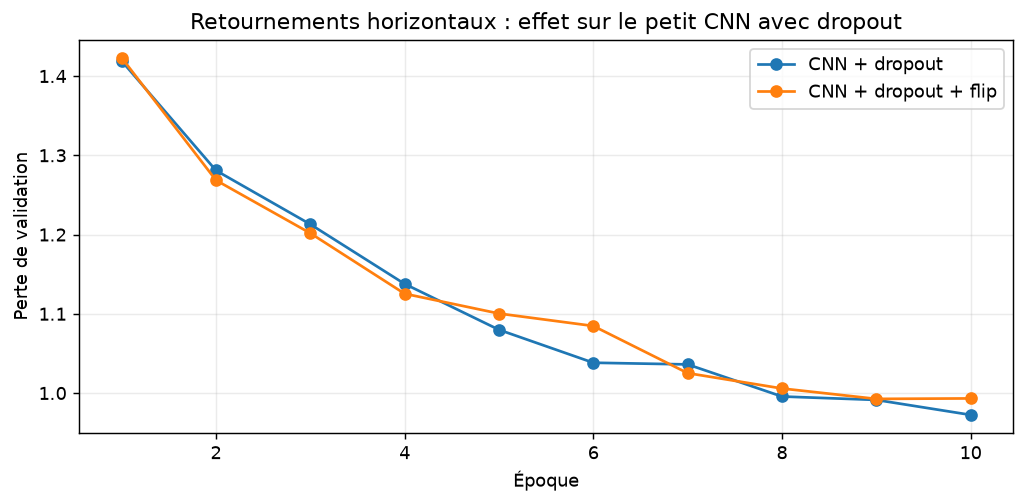

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for name in ("dropout", "augmentation"):
    history = histories[name]
    ax.plot(range(1, len(history["val_loss"])+1), history["val_loss"],
            marker="o", label=names[name])
ax.set(xlabel="Époque", ylabel="Perte de validation",
       title="Retournements horizontaux : effet sur le petit CNN avec dropout")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Évaluation des sauvegardes finales

Les données de test ne guident aucun réglage. Les deux modèles voient les mêmes exemples, avec leurs prétraitements respectifs. Une évaluation collecte simultanément perte, accuracy et prédictions : les matrices proviennent donc exactement des mêmes poids que les scores.

En mode rapport, les résultats sont chargés depuis le JSON vérifié. En mode évaluation, il faut fournir `models/cnn_improved_best.pth` et `models/resnet18_finetuned_best.pth`. Les fichiers existants ne sont jamais modifiés.

In [14]:
if MODE != "report":
    if MODE == "evaluate":
        cnn_path = MODEL_DIR / "cnn_improved_best.pth"
        resnet_path = MODEL_DIR / "resnet18_finetuned_best.pth"
    results = {"provenance": "Recomputed without parameter updates",
               "created_utc": datetime.now(timezone.utc).isoformat(), "models": {}}
    for name, path, transform, validation_loader in (
        ("cnn", cnn_path, plain_transform, val_loader),
        ("resnet18", resnet_path, resnet_transform, resnet_val_loader)
    ):
        if not path.is_file():
            raise FileNotFoundError(f"Poids requis : {path}. Utiliser report ou train si absents.")
        candidate = ImprovedCNN() if name == "cnn" else build_resnet()
        candidate.load_state_dict(torch.load(path, map_location="cpu", weights_only=True))
        candidate.to(device)
        validation, _, _ = evaluate(candidate, validation_loader)
        test_dataset = datasets.CIFAR10(str(DATA_DIR), train=False, download=True, transform=transform)
        test_loader = make_loader(test_dataset, BATCH_SIZE if name == "cnn" else RESNET_BATCH_SIZE)
        test, actuals, predictions = evaluate(candidate, test_loader, collect=True)
        matrix = [[0]*10 for _ in range(10)]
        for actual, predicted in zip(actuals, predictions):
            matrix[actual][predicted] += 1
        results["models"][name] = {
            "checkpoint": path.name, "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
            "parameters": sum(p.numel() for p in candidate.parameters()),
            "validation": validation, "test": test, "confusion_matrix": matrix,
            "predictions": predictions,
            "error_indices": [i for i,(a,p) in enumerate(zip(actuals,predictions)) if a != p]
        }
        candidate.cpu()
        del candidate
    with open(RUN_DIR / "results" / "verified_metrics.json", "w", encoding="utf-8") as file:
        json.dump(results, file, indent=2)
    print("Évaluation sauvegardée :", RUN_DIR)

In [15]:
rows = ["| Modèle | Accuracy validation | Accuracy test | Perte test |",
        "|---|---:|---:|---:|"]
for name, label in (("cnn", "CNN personnel"), ("resnet18", "ResNet18 fine-tuné")):
    record = results["models"][name]
    rows.append(f"| {label} | {record['validation']['accuracy']:.2%} | "
                f"{record['test']['accuracy']:.2%} | {record['test']['loss']:.4f} |")
display(Markdown("\n".join(rows)))
gain = results["models"]["resnet18"]["test"]["accuracy"] - results["models"]["cnn"]["test"]["accuracy"]
print(f"Gain : {100*gain:.2f} points de pourcentage.")
print(f"Bonnes réponses supplémentaires : {round(gain*10000)} sur 10 000.")

Gain : 4.26 points de pourcentage.
Bonnes réponses supplémentaires : 426 sur 10 000.


| Modèle | Accuracy validation | Accuracy test | Perte test |
|---|---:|---:|---:|
| CNN personnel | 86.79% | 85.88% | 0.4160 |
| ResNet18 fine-tuné | 90.61% | 90.14% | 0.3018 |

## 9. Matrices de confusion

Les lignes sont les vraies classes, les colonnes les prédictions. La diagonale contient les bonnes réponses. Le rappel d’une classe est sa diagonale divisée par le total de sa ligne. Ce n’est pas la précision par classe, qui utiliserait le total de la colonne.

Les deux graphiques utilisent la même échelle, de 0 à 1 000. Des vérifications relient leurs diagonales aux accuracies affichées, afin d’éviter les matrices anciennes restées en mémoire.

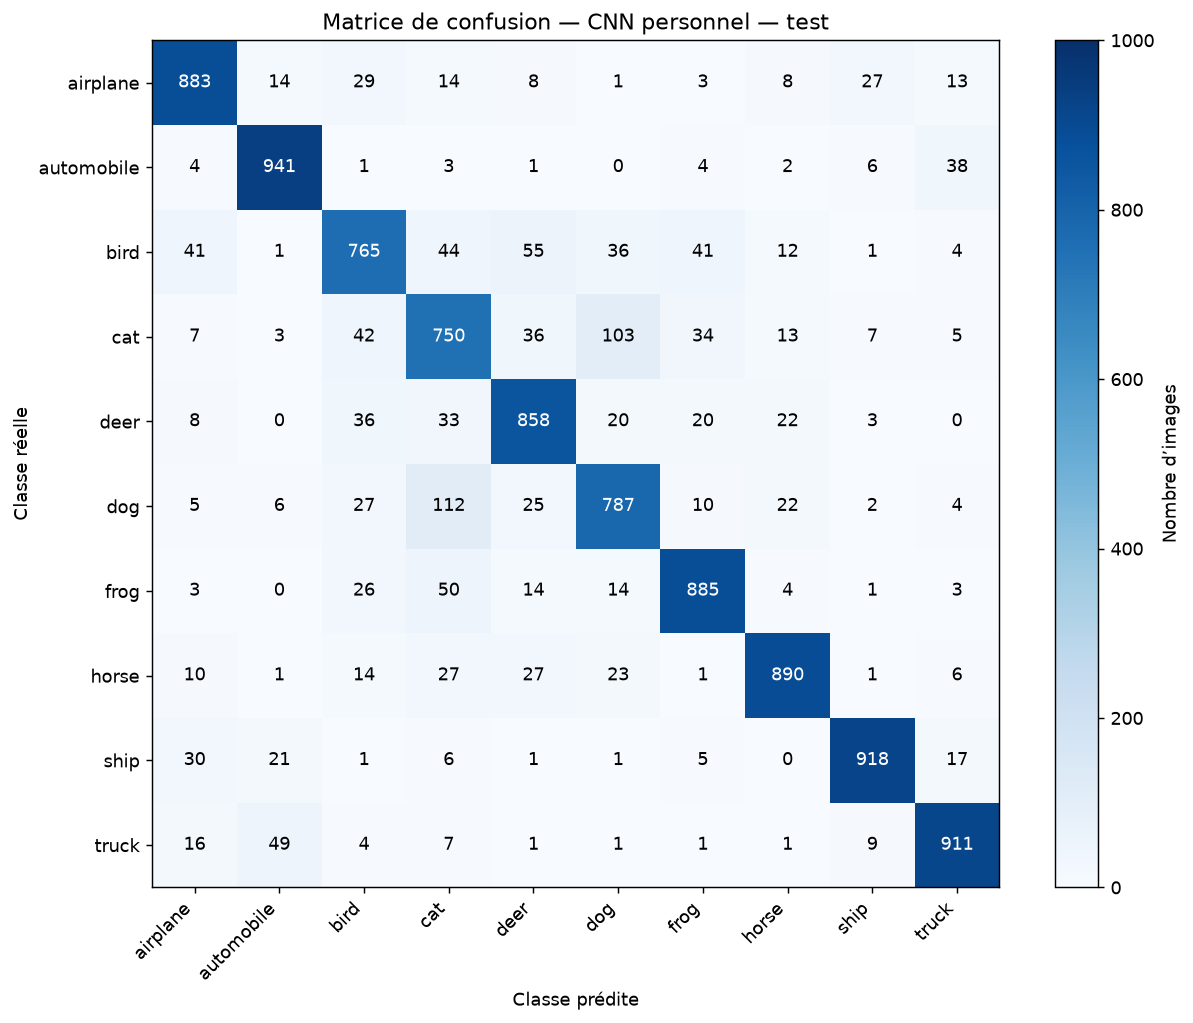

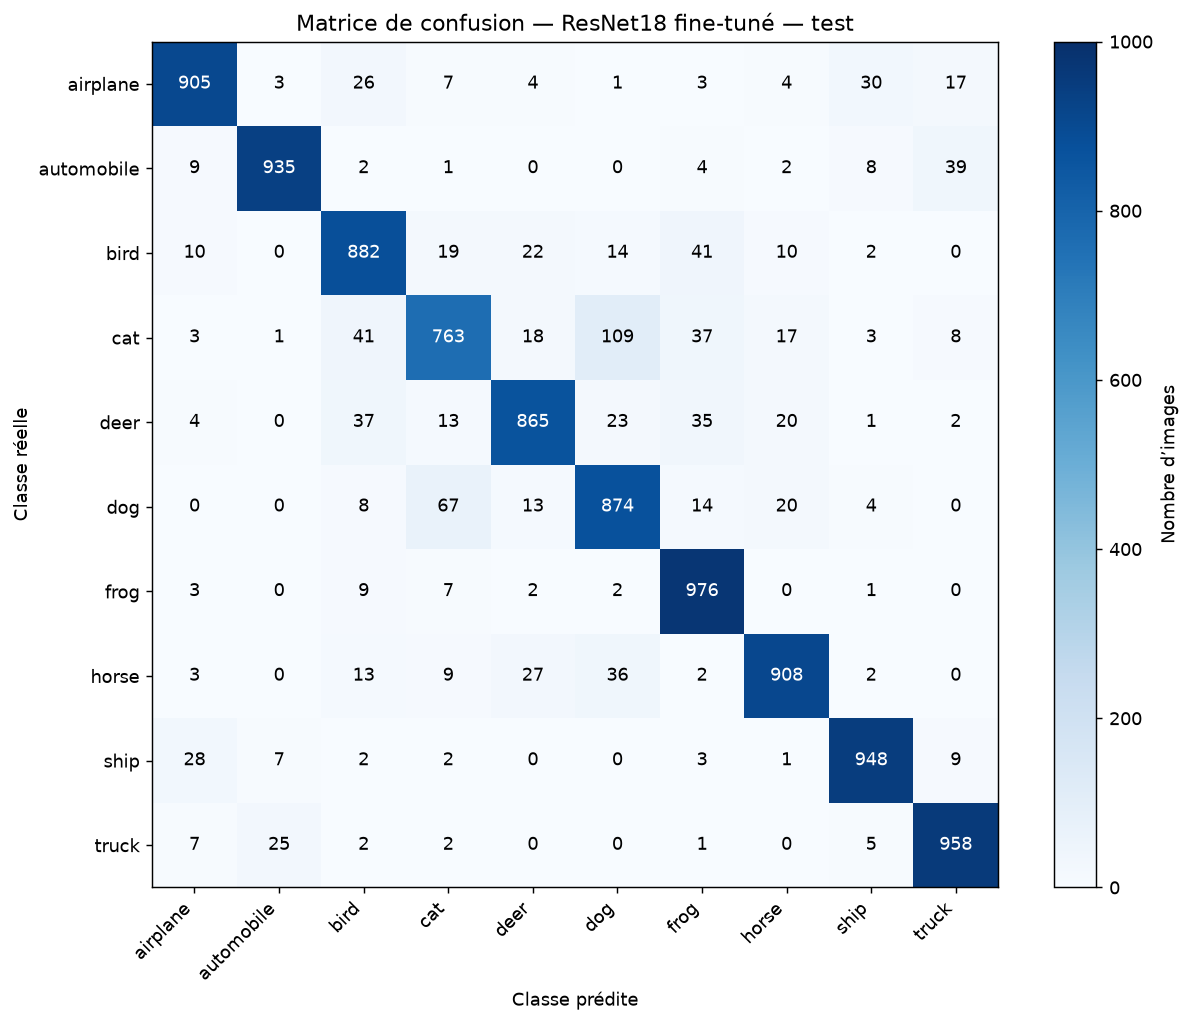

In [16]:
class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

def plot_confusion(matrix, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    heatmap = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=1000)
    fig.colorbar(heatmap, ax=ax, label="Nombre d’images")
    ax.set_xticks(range(10), labels=class_names, rotation=45, ha="right")
    ax.set_yticks(range(10), labels=class_names)
    ax.set(xlabel="Classe prédite", ylabel="Classe réelle", title=title)
    for row in range(10):
        for col in range(10):
            count = matrix[row][col]
            ax.text(col, row, str(count), ha="center", va="center",
                    color="white" if count > 500 else "black")
    plt.tight_layout()
    plt.show()

for name, label in (("cnn", "CNN personnel"), ("resnet18", "ResNet18 fine-tuné")):
    record = results["models"][name]
    matrix = record["confusion_matrix"]
    assert all(sum(row)==1000 for row in matrix)
    assert abs(sum(matrix[i][i] for i in range(10))/10000 - record["test"]["accuracy"]) < 1e-10
    plot_confusion(matrix, f"Matrice de confusion — {label} — test")

In [17]:
rows = ["| Classe | Rappel CNN | Rappel ResNet18 |", "|---|---:|---:|"]
for i, label in enumerate(class_names):
    recalls = []
    for name in ("cnn", "resnet18"):
        matrix = results["models"][name]["confusion_matrix"]
        recalls.append(matrix[i][i]/sum(matrix[i]))
    rows.append(f"| {label} | {recalls[0]:.1%} | {recalls[1]:.1%} |")
display(Markdown("\n".join(rows)))
for name in ("cnn", "resnet18"):
    matrix = results["models"][name]["confusion_matrix"]
    errors = sorted(((matrix[a][p], class_names[a], class_names[p])
                     for a in range(10) for p in range(10) if a != p), reverse=True)
    print(f"\n{name} — trois confusions les plus fréquentes :")
    for count, actual, predicted in errors[:3]:
        print(f"  {actual} → {predicted} : {count}")


cnn — trois confusions les plus fréquentes :
  dog → cat : 112
  cat → dog : 103
  bird → deer : 55

resnet18 — trois confusions les plus fréquentes :
  cat → dog : 109
  dog → cat : 67
  cat → bird : 41


| Classe | Rappel CNN | Rappel ResNet18 |
|---|---:|---:|
| airplane | 88.3% | 90.5% |
| automobile | 94.1% | 93.5% |
| bird | 76.5% | 88.2% |
| cat | 75.0% | 76.3% |
| deer | 85.8% | 86.5% |
| dog | 78.7% | 87.4% |
| frog | 88.5% | 97.6% |
| horse | 89.0% | 90.8% |
| ship | 91.8% | 94.8% |
| truck | 91.1% | 95.8% |

### Inspection qualitative des erreurs

Les huit premières erreurs ne sont pas un échantillon représentatif. Elles illustrent des cas difficiles sans démontrer les indices internes utilisés par le réseau. L’affichage utilise les images originales, sans la normalisation ImageNet.

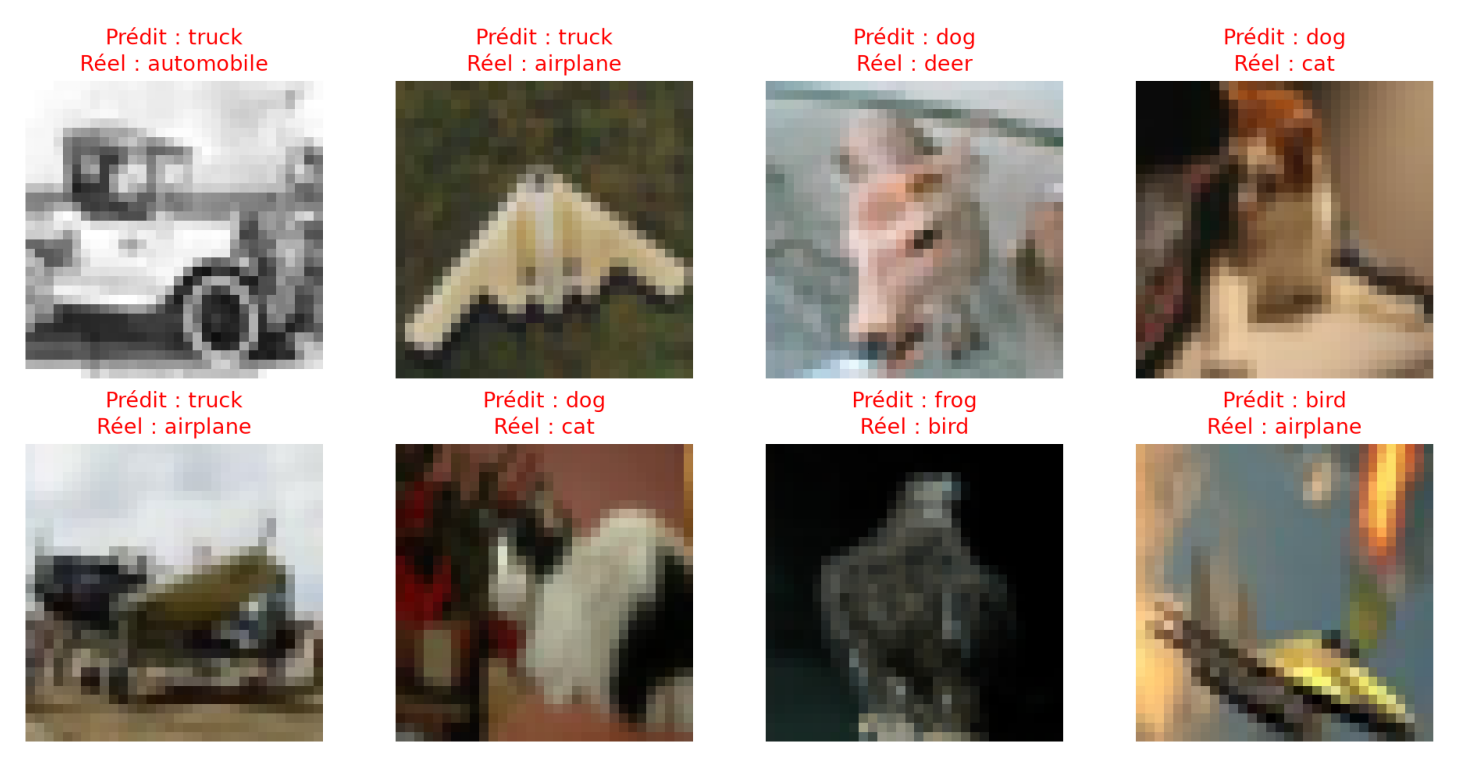

In [18]:
if MODE == "report":
    image = plt.imread(PROJECT_DIR / "figures" / "github_resnet_errors.png")
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(image)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    original_test = datasets.CIFAR10(str(DATA_DIR), train=False, download=False,
                                      transform=plain_transform)
    record = results["models"]["resnet18"]
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax in axes.flat:
        ax.axis("off")
    for ax, index in zip(axes.flat, record["error_indices"][:8]):
        image, actual = original_test[index]
        predicted = record["predictions"][index]
        ax.imshow(image.permute(1,2,0))
        ax.set_title(f"Prédit : {class_names[predicted]}\nRéel : {class_names[actual]}", color="red")
    plt.tight_layout()
    fig.savefig(RUN_DIR / "figures" / "resnet_errors.png", dpi=160, bbox_inches="tight")
    plt.show()

## 10. Bilan

Le projet montre trois niveaux d’amélioration : régulariser un petit CNN, augmenter sa capacité avec une architecture plus profonde, puis adapter un modèle préentraîné. Le dropout et les retournements n’apportent pas un bénéfice systématique ; le CNN amélioré et le fine-tuning apportent les gains les plus visibles dans les expériences conservées.

Les poids finaux vérifiés donnent **85,88 % pour le CNN personnel** et **90,14 % pour ResNet18**, soit **4,26 points** d’écart. Ces chiffres décrivent les sauvegardes publiées dans ce rapport, pas nécessairement une future exécution en mode train.

### Limites et interprétation

- Une exécution par configuration est rapportée : aucune moyenne ni dispersion entre graines.
- Le CNN amélioré change plusieurs composants simultanément ; l’effet de chacun n’est pas isolé.
- Les budgets, résolutions et augmentations diffèrent entre CNN et ResNet18 ; ImageNet fournit des données externes au second.
- L’ancien historique incomplet de référence n’est pas utilisé pour chiffrer un gain.
- La validation a guidé les essais. Le test a été réévalué pour vérifier les sauvegardes et la cohérence des figures, sans nouveau réglage issu de ces résultats.
- CIFAR-10 ne garantit pas une performance identique sur des photos personnelles.
- Les fichiers `.pth` contiennent les paramètres et buffers, mais pas l’état d’Adam : ils permettent l’inférence, pas une reprise strictement identique de l’entraînement.

### Compétences mises en pratique

Préparer des tenseurs et des datasets, contrôler les dimensions, construire un CNN, calculer les gradients, suivre les courbes, gérer les modes train/eval, sauvegarder selon la validation, pratiquer le transfert d’apprentissage, analyser les erreurs et documenter les limites.

## Références

- [CIFAR-10 — page du dataset](https://www.cs.toronto.edu/~kriz/cifar.html)
- [Documentation PyTorch](https://docs.pytorch.org/docs/stable/index.html)
- [ResNet18 — torchvision](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html)
- [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385)

Le dépôt doit contenir ce notebook, `results/experiment_histories.json`, `results/verified_metrics.json` et les figures nécessaires au mode rapport. L’installation de PyTorch/CUDA et l’accès aux poids doivent être expliqués dans le README.